# 03 - Sparse Autoencoder Training & Semantic Grounding

## 1. Setup and Imports
Configure paths to seamlessly run on Colab or locally, and install required libraries.

In [1]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    base_dir = '/content/drive/MyDrive/xai-project5'
else:
    base_dir = os.path.abspath(os.path.join('..', '..'))

feat_dir = os.path.join(base_dir, 'src', 'results', '01_feature_extraction')
dict_dir = os.path.join(base_dir, 'src', 'results', '02_dictionary_creation')
save_dir = os.path.join(base_dir, 'src', 'results', '03_sae_training')
scripts_path = os.path.join(base_dir, 'src', 'scripts')
req_path = os.path.join(base_dir, 'requirements.txt')

os.makedirs(save_dir, exist_ok=True)

if scripts_path not in sys.path:
    sys.path.append(scripts_path)

print(f"Setup complete.\nOutput directory: {save_dir}")


Setup complete.
Output directory: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/03_sae_training


In [2]:
!pip install -q -r "{req_path}"


In [15]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import open_clip
from datasets import load_dataset

from sae import SparseAutoencoder, sae_loss_function

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 2. Data Loading

In [6]:
print("Loading visual tensors (NIH dataset)...")

train_feat_path = os.path.join(feat_dir, "biomedclip_nih_embeddings_train.pt")
test_feat_path = os.path.join(feat_dir, "biomedclip_nih_embeddings_test.pt")

try:
    X_train = torch.load(train_feat_path, map_location=device)
    X_val = torch.load(test_feat_path, map_location=device)
    
    print(f"Training set shape (X_train): {X_train.shape}")
    print(f"Validation set shape (X_val): {X_val.shape}")
except FileNotFoundError as e:
    print(f"Error: Tensors not found. Did you complete the extraction in Notebook 01?\n{e}")
    sys.exit(1)

# Create DataLoaders to manage batches during training
BATCH_SIZE = 256

train_dataset = TensorDataset(X_train)
val_dataset = TensorDataset(X_val)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of batches per epoch (Train): {len(train_dataloader)}")
print(f"Number of batches per epoch (Val): {len(val_dataloader)}")

Loading visual tensors (NIH dataset)...
Training set shape (X_train): torch.Size([7500, 512])
Validation set shape (X_val): torch.Size([2500, 512])
Number of batches per epoch (Train): 30
Number of batches per epoch (Val): 10


## 3. Sparse Autoencoder Training

**Sparse Autoencoders (SAEs)** implement a form of *sparse dictionary learning*, aiming to learn a sparse decomposition of a signal into an overcomplete dictionary of atoms.

Given an embedding $v \in \mathbb{R}^d$, the SAE decomposes the vector into:
- **Activation vector**: $\phi(v) := \sigma(W_{enc}^{\top}(v - b))$
- **Reconstructed vector**: $\hat{v} := W_{dec}^{\top}\phi(v) + b$

The loss function combines a **reconstruction objective** with a **sparsity regularization**:
$$\mathcal{L}(v) = R(v) + \lambda S(v)$$
where $R(v) = \|v - \hat{v}\|_2^2$ (L2 Loss) and $S(v) = \|\phi(v)\|_1$ (L1 Loss).

In [35]:
INPUT_DIM = X_train.shape[1]
HIDDEN_DIM = 1024
LR = 1e-3
L1_LAMBDA = 0.05
EPOCHS = 1000

sae = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)
optimizer = optim.Adam(sae.parameters(), lr=LR)
# We cut the LR by half (factor=0.5) if the loss doesn't improve for 10 epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print(f"SAE inizializzato con successo!")

SAE inizializzato con successo!


In [36]:
# The model is saved as: sae_model_final_e{EPOCHS}_l{L1_LAMBA}_h{HIDDEN_DIM}
model_name = f'e{EPOCHS}_l{L1_LAMBDA}_h{HIDDEN_DIM}'

checkpoint_path = os.path.join(save_dir, f'sae_checkpoint_{model_name}.pt')
best_model_path = os.path.join(save_dir, f'sae_model_best_{model_name}.pt')
final_model_path = os.path.join(save_dir, f'sae_model_final_{model_name}.pt')

start_epoch = 0
history = {'total': [], 'mse': [], 'l1': [], 'lr': [], 'val_total': []}

# Early stopping parameters
EARLY_STOPPING_PATIENCE = 25
best_val_loss = float('inf')
patience_counter = 0

RESUME_TRAINING = False

# Resume from checkpoint if interrupted
if RESUME_TRAINING and os.path.exists(checkpoint_path):
    print("Found training checkpoint! Resuming...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    sae.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    history = checkpoint['history']
    
    # Restore early stopping state if it exists in checkpoint
    if 'best_val_loss' in checkpoint:
        best_val_loss = checkpoint['best_val_loss']
    if 'patience_counter' in checkpoint:
        patience_counter = checkpoint['patience_counter']
        
    if 'lr' not in history:
        history['lr'] = []
    if 'val_total' not in history:
        history['val_total'] = []
    
    print(f"Resuming from epoch {start_epoch + 1}...")
else:
    print("Starting a new training")

print("\n--- STARTING SAE TRAINING ---")
for epoch in range(start_epoch, EPOCHS):
    ### --- Train phase ---
    sae.train()

    epoch_total_loss = 0.0
    epoch_mse_loss = 0.0
    epoch_l1_loss = 0.0

    for batch in train_dataloader:
        x = batch[0].to(device)
        
        # Forward pass
        x_hat, z = sae(x)
        
        # Calculate loss
        total_loss, mse_loss, l1_loss = sae_loss_function(x, x_hat, z, L1_LAMBDA)
        
        # Backward and optimize
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Normalize decoder weights to prevent collapse (force norm=1)
        sae.normalize_decoder_weights()

        epoch_total_loss += total_loss.item()
        epoch_mse_loss += mse_loss.item()
        epoch_l1_loss += l1_loss.item()
    
    avg_total_loss = epoch_total_loss / len(train_dataloader)
    avg_mse = epoch_mse_loss / len(train_dataloader)
    avg_l1 = epoch_l1_loss / len(train_dataloader)

    ### --- Validation Phase ---
    sae.eval()

    val_total_loss = 0.0

    with torch.no_grad():
        for batch in val_dataloader:
            x = batch[0].to(device)
            x_hat, z = sae(x)
            
            loss, _, _ = sae_loss_function(x, x_hat, z, L1_LAMBDA)
            val_total_loss += loss.item()
            
    avg_val_loss = val_total_loss / len(val_dataloader)
    
    # Step the scheduler based on the average validation loss
    scheduler.step(avg_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']

    history['total'].append(avg_total_loss)
    history['mse'].append(avg_mse)
    history['l1'].append(avg_l1)
    history['lr'].append(current_lr)
    history['val_total'].append(avg_val_loss)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
          f"LR: {current_lr:.2e} | "
          f"Train Loss: {avg_total_loss:.4e} | "
          f"Val Loss: {avg_val_loss:.4e} | "
          f"MSE: {avg_mse:.4e} | "
          f"L1: {avg_l1:.4e}")
          
    # Check for early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save the absolute best weights so far
        torch.save(sae.state_dict(), best_model_path)
    else:
        patience_counter += 1
        print(f"  -> Early stopping counter: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
        
    # Save checkpoint at the end of each epoch (added early stopping state)
    torch.save({
        'epoch': epoch,
        'model_state_dict': sae.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'best_val_loss': best_val_loss,
        'patience_counter': patience_counter
    }, checkpoint_path)

    # Break the loop if patience is reached
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}! Validation loss hasn't improved for {EARLY_STOPPING_PATIENCE} epochs.")
        break

# Save final model properly for Notebook 04
torch.save(sae.state_dict(), final_model_path)
print(f"\nTraining complete!")
print(f"Best model saved to: {best_model_path} (USE THIS FOR EVALUATION)")
print(f"Final epoch model saved to: {final_model_path}")

Starting a new training

--- STARTING SAE TRAINING ---
Epoch [01/1000] | LR: 1.00e-03 | Train Loss: 6.9910e-04 | Val Loss: 3.8230e-04 | MSE: 4.3638e-04 | L1: 5.2544e-03
Epoch [02/1000] | LR: 1.00e-03 | Train Loss: 3.1659e-04 | Val Loss: 2.6527e-04 | MSE: 1.6175e-04 | L1: 3.0969e-03
Epoch [03/1000] | LR: 1.00e-03 | Train Loss: 2.3366e-04 | Val Loss: 2.0774e-04 | MSE: 1.1028e-04 | L1: 2.4678e-03
Epoch [04/1000] | LR: 1.00e-03 | Train Loss: 1.8949e-04 | Val Loss: 1.7447e-04 | MSE: 8.7602e-05 | L1: 2.0377e-03
Epoch [05/1000] | LR: 1.00e-03 | Train Loss: 1.6380e-04 | Val Loss: 1.5512e-04 | MSE: 7.5880e-05 | L1: 1.7584e-03
Epoch [06/1000] | LR: 1.00e-03 | Train Loss: 1.4829e-04 | Val Loss: 1.4350e-04 | MSE: 6.8463e-05 | L1: 1.5966e-03
Epoch [07/1000] | LR: 1.00e-03 | Train Loss: 1.3867e-04 | Val Loss: 1.3577e-04 | MSE: 6.3460e-05 | L1: 1.5043e-03
Epoch [08/1000] | LR: 1.00e-03 | Train Loss: 1.3221e-04 | Val Loss: 1.3063e-04 | MSE: 5.9845e-05 | L1: 1.4473e-03
Epoch [09/1000] | LR: 1.00e-03 | 

## 4. Training Data Analysis
Let's visualize the training metrics to ensure the SAE converged properly and correctly balanced the trade-off between Reconstruction (MSE) and Sparsity (L1).

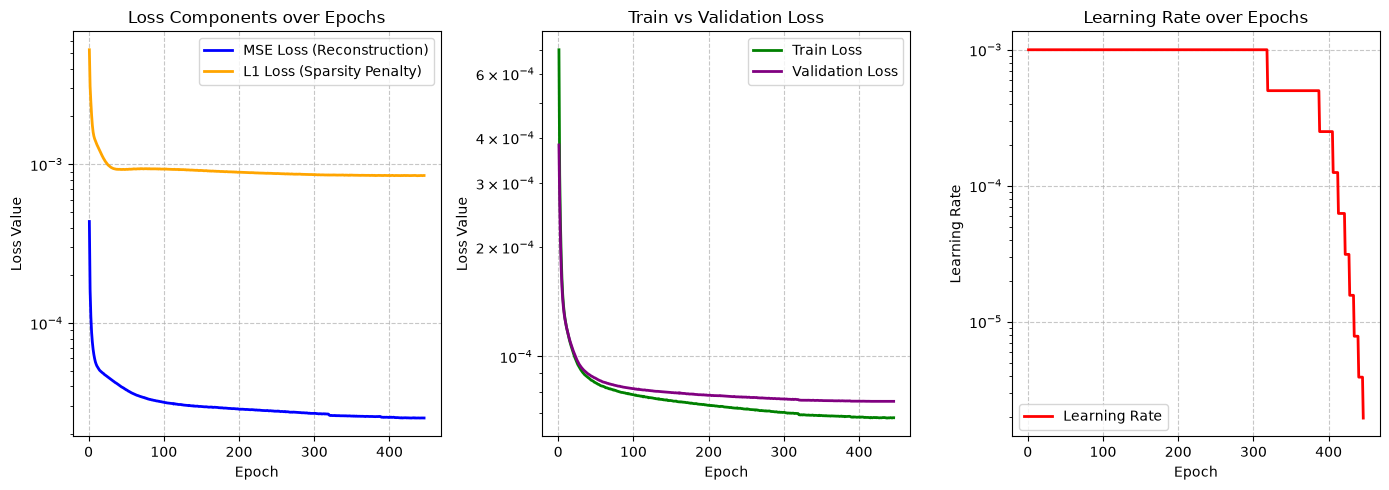

In [37]:
epochs_range = range(1, len(history['total']) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Reconstruction vs Sparsity Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history['mse'], label='MSE Loss (Reconstruction)', color='blue', linewidth=2)
plt.plot(epochs_range, history['l1'], label='L1 Loss (Sparsity Penalty)', color='orange', linewidth=2)
plt.title('Loss Components over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.yscale('log') # Log scale for better visibility if differences are huge
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Total Train vs Validation Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history['total'], label='Train Loss', color='green', linewidth=2)
if 'val_total' in history and len(history['val_total']) == len(epochs_range):
    plt.plot(epochs_range, history['val_total'], label='Validation Loss', color='purple', linewidth=2)
plt.title('Train vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.yscale('log') # Added log scale here too, as total loss usually drops exponentially
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 3: Learning Rate
plt.subplot(1, 3, 3)
if 'lr' in history and len(history['lr']) == len(epochs_range):
    plt.plot(epochs_range, history['lr'], label='Learning Rate', color='red', linewidth=2)
plt.title('Learning Rate over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

## 4.5 Model Evaluation & Sparsity Check
In this section, we load the trained weights of a specific Sparse Autoencoder model to evaluate its performance on an unseen validation batch. 

We assess two primary metrics:
1. **Reconstruction Quality**: Measured via Mean Squared Error (MSE) and Cosine Similarity, this tells us how accurately the SAE can reconstruct the original image embeddings.
2. **Sparsity (L0 Norm)**: We calculate the average number of active (non-zero) hidden features per embedding. This tells us how effectively the model has compressed the dense representation into a sparse, interpretable format.


In [38]:
INPUT_DIM = X_train.shape[1]
HIDDEN_DIM = 1024
sae = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)

selected_model = 'sae_model_best_e1000_l0.05_h1024.pt' 
weights_path = os.path.join(save_dir, selected_model)
print(f"\nAttempting to load weights from: {weights_path}")

try:
    checkpoint = torch.load(weights_path, map_location=device)
    
    # Check if the file is a full checkpoint dictionary (with optimizer state) or just the raw model weights
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        sae.load_state_dict(checkpoint['model_state_dict'])
        print("\nFull checkpoint detected. Model weights loaded successfully!")
    else:
        sae.load_state_dict(checkpoint)
        print("\nRaw model weights loaded successfully!")
except Exception as e:
    print(f"\nError loading weights: {e}")

# Put the model in evaluation mode
sae.eval()

# Get a single batch from the validation dataloader
x_batch = next(iter(val_dataloader))[0].to(device)

with torch.no_grad():
    # Forward pass through the SAE
    x_hat, z = sae(x_batch)
    
    # Calculate Average L0 Sparsity (how many features are active per embedding)
    active_features_per_sample = (z > 0).sum(dim=1).float()
    avg_active_features = active_features_per_sample.mean().item()
    
    # Calculate Reconstruction Quality (Cosine Similarity)
    cos_sim = F.cosine_similarity(x_batch, x_hat, dim=1)
    avg_cos_sim = cos_sim.mean().item()
    
    # Mean Squared Error (MSE)
    mse = F.mse_loss(x_hat, x_batch).item()

hidden_dim = sae.encoder.out_features

print("\n--- SAE Evaluation on a Validation Batch ---")
print(f"Batch size evaluated: {x_batch.shape[0]}")
print(f"SAE hidden dimensions: {hidden_dim}")
print(f"Average Active Features (L0): {avg_active_features:.1f} out of {hidden_dim}")
print(f"Average Cosine Similarity:    {avg_cos_sim:.4f} (1.0000 is perfect)")
print(f"Mean Squared Error:           {mse:.4e} (0.0000 is perfect)")


Attempting to load weights from: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/03_sae_training/sae_model_best_e1000_l0.05_h1024.pt

Raw model weights loaded successfully!

--- SAE Evaluation on a Validation Batch ---
Batch size evaluated: 256
SAE hidden dimensions: 1024
Average Active Features (L0): 46.2 out of 1024
Average Cosine Similarity:    0.9917 (1.0000 is perfect)
Mean Squared Error:           3.2501e-05 (0.0000 is perfect)


## 5. Global Explainability: Semantic Grounding

Global explainability aims to map and understand the model's internal architecture in its entirety, independently of individual input samples. In this paradigm, the goal is to build a dictionary that connects the latent visual concepts—learned in a totally unsupervised manner—to human language.

This process, known as *semantic grounding*, is achieved by computing the cosine similarity between the textual embeddings of known clinical concepts (from Notebook 02) and the decoder dictionary learned by the Sparse Autoencoder.

Since both vectors are subjected to L2 normalization, calculating the cosine similarity elegantly reduces to a single matrix multiplication: $S = T \cdot W_{dec}$, where $T$ represents the text embeddings matrix and $W_{dec}$ is the SAE decoder dictionary. This geometric operation allows us to establish the "at-rest" alignment of the network, assigning the most strongly connected latent neuron to each medical phrase.

In [8]:
# Load the Phrase-Level Concept Matrix and Metadata
matrix_path = os.path.join(dict_dir, 'biomedclip_phrase_level_concept_matrix.pt')
metadata_path = os.path.join(dict_dir, 'biomedclip_phrase_level_metadata.csv')

print(f"Loading Phrase-Level Concept Matrix from: {matrix_path}")
T_phrases = torch.load(matrix_path, map_location=device)

print(f"Loading Phrase Metadata from: {metadata_path}")
phrase_metadata = pd.read_csv(metadata_path)

print(f"\nShape of T_phrases matrix: {T_phrases.shape}")

Loading Phrase-Level Concept Matrix from: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/02_dictionary_creation/biomedclip_phrase_level_concept_matrix.pt
Loading Phrase Metadata from: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/02_dictionary_creation/biomedclip_phrase_level_metadata.csv

Shape of T_phrases matrix: torch.Size([998, 512])


In [9]:
# Define the SAE and load the best evaluation weights
selected_model = 'sae_model_best_e1000_l0.05_h1024.pt' 
eval_model_path = os.path.join(save_dir, selected_model)
print(f"Loading SAE weights from: {eval_model_path}")

INPUT_DIM = X_train.shape[1]
HIDDEN_DIM = 1024
sae = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)
sae.load_state_dict(torch.load(eval_model_path, map_location=device))
sae.eval()

Loading SAE weights from: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/03_sae_training/sae_model_best_e1000_l0.05_h1024.pt


SparseAutoencoder(
  (encoder): Linear(in_features=512, out_features=1024, bias=True)
  (decoder): Linear(in_features=1024, out_features=512, bias=False)
)

In [10]:
# Compute Cosine Similarity for all phrases
with torch.no_grad():
    sae_dictionary = F.normalize(sae.decoder.weight.data, p=2, dim=0)
    
    # T_phrases is already L2-normalized from Step 02
    # similarities shape: [998, 1024]
    phrase_similarities = torch.matmul(T_phrases, sae_dictionary)

# Aggregate activations per parent clinical concept
parent_concepts = phrase_metadata['parent_concept'].unique()
num_concepts = len(parent_concepts)
num_neurons = HIDDEN_DIM

# Initialize the aggregated similarity matrix
concept_similarities = torch.zeros((num_concepts, num_neurons), device=device)

for idx, concept in enumerate(parent_concepts):
    # Retrieve all rows associated with the parent concept
    phrase_indices = phrase_metadata.index[phrase_metadata['parent_concept'] == concept].tolist()
    
    # Extract similarities for these specific phrases
    concept_phrase_sims = phrase_similarities[phrase_indices]
    
    # Max Pooling: Take the highest similarity score a phrase achieved for each neuron
    aggregated_sims, _ = torch.max(concept_phrase_sims, dim=0)
    concept_similarities[idx] = aggregated_sims

# Maintain namespace compatibility for Section 5 (Local Explainability)
similarities = concept_similarities
medical_concepts = parent_concepts.tolist()

print(f"Aggregated similarities matrix shape: {similarities.shape}")

# Display a sample of the semantic grounding
top_k = 10
sample_size = min(5, num_concepts)
print(f"\nShowing Grounding for the first {sample_size} parent concepts:\n")

for idx in range(sample_size):
    concept = medical_concepts[idx]
    concept_sims = similarities[idx]
    
    top_values, top_indices = torch.topk(concept_sims, top_k)
    
    print(f"Parent Clinical Concept: '{concept}'")
    for i in range(top_k):
        print(f"  -> SAE Neuron {top_indices[i].item():4d} (Max Similarity: {top_values[i].item():.4f})")
    print("-" * 40)

Aggregated similarities matrix shape: torch.Size([100, 1024])

Showing Grounding for the first 5 parent concepts:

Parent Clinical Concept: 'lung'
  -> SAE Neuron  502 (Max Similarity: 0.2139)
  -> SAE Neuron  400 (Max Similarity: 0.2108)
  -> SAE Neuron  894 (Max Similarity: 0.2046)
  -> SAE Neuron  940 (Max Similarity: 0.2032)
  -> SAE Neuron  379 (Max Similarity: 0.1926)
  -> SAE Neuron  967 (Max Similarity: 0.1865)
  -> SAE Neuron  160 (Max Similarity: 0.1863)
  -> SAE Neuron  868 (Max Similarity: 0.1848)
  -> SAE Neuron  223 (Max Similarity: 0.1832)
  -> SAE Neuron  346 (Max Similarity: 0.1829)
----------------------------------------
Parent Clinical Concept: 'lung opacity'
  -> SAE Neuron  969 (Max Similarity: 0.2505)
  -> SAE Neuron  688 (Max Similarity: 0.2382)
  -> SAE Neuron  967 (Max Similarity: 0.2100)
  -> SAE Neuron  885 (Max Similarity: 0.2039)
  -> SAE Neuron   66 (Max Similarity: 0.2018)
  -> SAE Neuron  690 (Max Similarity: 0.2010)
  -> SAE Neuron   47 (Max Similarity

## 6. Local Explainability: Dissecting a Single Clinical Case

While global explainability defines the network's vocabulary, local explainability investigates its dynamic behavior when faced with a specific input sample (e.g., a single patient's chest X-ray).

### Translating Activations into Diagnosis
When a raw X-ray image is processed by BioMedCLIP and forwarded through the SAE, the network responds by firing a highly sparse activation vector $z$. 
1. The script captures the top most intensely fired neurons.
2. It queries the global similarity matrix $S$ to find the medical label closest to those active channels.
3. It outputs a human-readable explanation, pinpointing exactly what visual pathologies the AI detected in that specific image, converting abstract dimensions into transparent, clinical insights.

In [24]:
def explain_single_image(path, vlm_model, preprocess, sae_model, concept_similarities, concept_names, device, top_k_neurons=10):
    vlm_model.eval()
    sae_model.eval()
    
    # Using a dummy image if path doesn't exist just for demonstration purposes
    if not os.path.exists(path):
        print(f"Image not found at {path}. Using a blank dummy image to test logic.")
        import numpy as np
        image = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
    else:
        image = Image.open(path)

    if image.mode != "RGB":
        image = image.convert("RGB")

    image_input = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        # Estraiamo l'embedding dell'immagine con open_clip
        vision_features = vlm_model.encode_image(image_input)
        
        # Normalizzazione L2 obbligatoria
        vision_embeddings = F.normalize(vision_features, p=2, dim=1)

        # Passaggio nel Sparse Autoencoder
        _, z = sae_model(vision_embeddings)

    activations = z[0] # Extracting the activation vector
    top_activation_values, top_neuron_indices = torch.topk(activations, top_k_neurons)

    found_concepts = False
    for val, neuron_idx in zip(top_activation_values, top_neuron_indices):
        #if val.item() <= 0.05:
        #    continue
            
        found_concepts = True
        print(f"\n[Neuron {neuron_idx.item():4d}] -> Activation Intensity: {val.item():.4f}")
        neuron_concept_scores = concept_similarities[:, neuron_idx]
        
        best_concept_idx = torch.argmax(neuron_concept_scores).item()
        best_concept_score = neuron_concept_scores[best_concept_idx].item()
        
        print(f"  Top Semantic Concept: '{concept_names[best_concept_idx]}'")
        print(f"  Grounding Score: {best_concept_score:.4f}")

    if not found_concepts:
        print("\nNo sufficient strong activations found for this image.")

In [19]:
# We load the VLM processor and model specifically for the local explanation test
print("Caricamento di BioMedCLIP per l'Explainability Locale...")
model_name = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
vlm_model, _, preprocess = open_clip.create_model_and_transforms(model_name)
vlm_model = vlm_model.to(device)

# Load the NIH dataset (same split used for feature extraction)
print("\nLoading NIH Chest X-ray dataset to fetch a real sample...")
nih_dataset = load_dataset("g-ronimo/NIH-Chest-X-ray-dataset_10k", split="train")

Caricamento di BioMedCLIP per l'Explainability Locale...

Loading NIH Chest X-ray dataset to fetch a real sample...


In [27]:
# Define the manual label mapping
NIH_LABELS_MAP = {
    0: "Atelectasis",
    1: "Cardiomegaly",
    2: "Effusion",
    3: "Infiltration",
    4: "Mass",
    5: "Nodule",
    6: "Pneumonia",
    7: "Pneumothorax",
    8: "Consolidation",
    9: "Edema",
    10: "Emphysema",
    11: "Fibrosis",
    12: "Pleural_Thickening",
    13: "Hernia"
}

In [32]:
# Select a specific sample index
sample_idx = 4  # Change this to test different clinical cases
sample = nih_dataset[sample_idx]

# Extract the PIL image and the integer labels
pil_image = sample['image']
label_indices = sample.get('labels', [])

# Decode integer labels using the manual dictionary
# Using .get() ensures it won't crash if an unexpected integer appears
ground_truth_labels = [NIH_LABELS_MAP.get(idx, f"Unknown Label ({idx})") for idx in label_indices]

# If the list is empty, it means the X-ray is healthy
if not ground_truth_labels:
    ground_truth_labels = ["No Finding"]

# Save temporarily so the explain_single_image function can load it from a path
test_image_path = os.path.join(base_dir, 'src', 'images', f'nih_test_sample_{sample_idx}.jpg')
os.makedirs(os.path.dirname(test_image_path), exist_ok=True)
pil_image.convert("RGB").save(test_image_path)

print(f"\n" + "="*50)
print(f"CLINICAL GROUND TRUTH FOR IMAGE {sample_idx}:")
print(f"Labels: {ground_truth_labels}")
print("="*50)

# Run the explainability pipeline on the real chest X-ray
explain_single_image(
    path=test_image_path, 
    vlm_model=vlm_model, 
    preprocess=preprocess, 
    sae_model=sae, 
    concept_similarities=similarities, 
    concept_names=medical_concepts, 
    device=device
)


CLINICAL GROUND TRUTH FOR IMAGE 4:
Labels: ['Fibrosis', 'Hernia']

[Neuron  551] -> Activation Intensity: 0.0487
  Top Semantic Concept: 'cholelithiasis'
  Grounding Score: 0.2454

[Neuron  518] -> Activation Intensity: 0.0377
  Top Semantic Concept: 'pulmonary airspace disease'
  Grounding Score: 0.3338

[Neuron  345] -> Activation Intensity: 0.0373
  Top Semantic Concept: 'bone sclerosis'
  Grounding Score: 0.2353

[Neuron  986] -> Activation Intensity: 0.0322
  Top Semantic Concept: 'cardiomegaly'
  Grounding Score: 0.3429

[Neuron  546] -> Activation Intensity: 0.0272
  Top Semantic Concept: 'pulmonary consolidation'
  Grounding Score: 0.2165

[Neuron  507] -> Activation Intensity: 0.0270
  Top Semantic Concept: 'heart atria'
  Grounding Score: 0.1935

[Neuron  610] -> Activation Intensity: 0.0264
  Top Semantic Concept: 'mediastinal shift'
  Grounding Score: 0.1599

[Neuron   64] -> Activation Intensity: 0.0262
  Top Semantic Concept: 'bone and bones'
  Grounding Score: 0.2178

[